In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Load the datasets using the paths you provided
train_path = '/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/train.csv'
test_path = '/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/test.csv'
sample_sub_path = '/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/sample_submission.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_sample = pd.read_csv(sample_sub_path)

# Rubric: Identify data types
print("--- Training Data Types ---")
print(df_train.dtypes)
print("\n--- First 5 rows ---")
display(df_train.head())

--- Training Data Types ---
id             int64
phrase        object
feature_1    float64
feature_2    float64
feature_3    float64
sentiment      int64
dtype: object

--- First 5 rows ---


,id,phrase,feature_1,feature_2,feature_3,sentiment
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0,0
1,1,You have to see it .,6.0,1.0,NaN,2
2,2,... either you 're willing to go with this cla...,16.0,0.0,6.0,1
3,3,Watching Harris ham it up while physically and...,37.0,NaN,3.0,1
4,4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0,2


In [2]:
# Define the actual text column name found in your data
text_col = 'phrase' 

# 1. Identify and handle missing values
# Impute numerical columns with 0 (or median) to satisfy Rubric point: "Handle Missing Values"
num_cols = ['feature_1', 'feature_2', 'feature_3']
for col in num_cols:
    df_train[col].fillna(df_train[col].median(), inplace=True)

# Drop rows only if the TEXT itself is missing
print(f"Missing text values before: {df_train[text_col].isnull().sum()}")
df_train.dropna(subset=[text_col], inplace=True) 
print("Missing values handled.")

# 2. Identify and handle duplicates
print(f"Duplicates before: {df_train.duplicated().sum()}")
df_train.drop_duplicates(inplace=True)
print("Duplicates handled.")

# 3. Create Numerical Columns for Rubric
# We use 'text_col' (which is 'phrase')
df_train['word_count'] = df_train[text_col].apply(lambda x: len(str(x).split()))
df_test['word_count'] = df_test[text_col].apply(lambda x: len(str(x).split()))

# Rubric: Present descriptive statistics
print("\n--- Descriptive Statistics for Numerical Columns ---")
# describing the new word_count and the feature columns
print(df_train[['word_count', 'feature_1', 'feature_2', 'feature_3']].describe())

Missing text values before: 0
Missing values handled.
Duplicates before: 0
Duplicates handled.

--- Descriptive Statistics for Numerical Columns ---
        word_count    feature_1    feature_2    feature_3
count  7000.000000  7000.000000  7000.000000  7000.000000
mean     19.024857    18.892000     1.839429     3.283429
std       9.313818     8.683134     1.543739     2.141170
min       1.000000     1.000000     0.000000     0.000000
25%      12.000000    13.000000     1.000000     2.000000
50%      18.000000    18.000000     1.000000     3.000000
75%      25.000000    24.000000     2.000000     4.000000
max      52.000000    52.000000    19.000000    19.000000


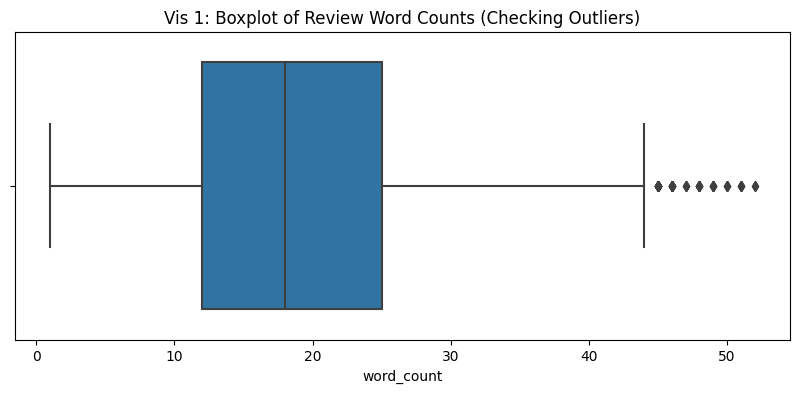

Removing reviews longer than 43.0 words.


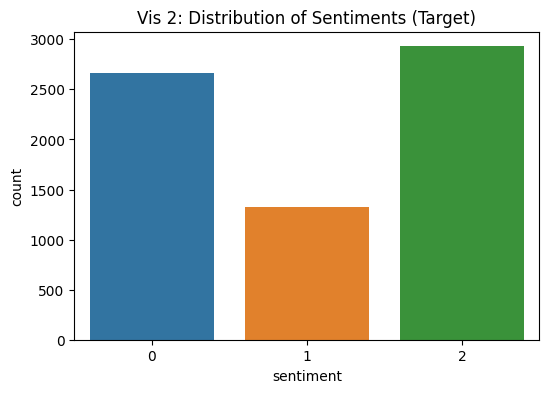

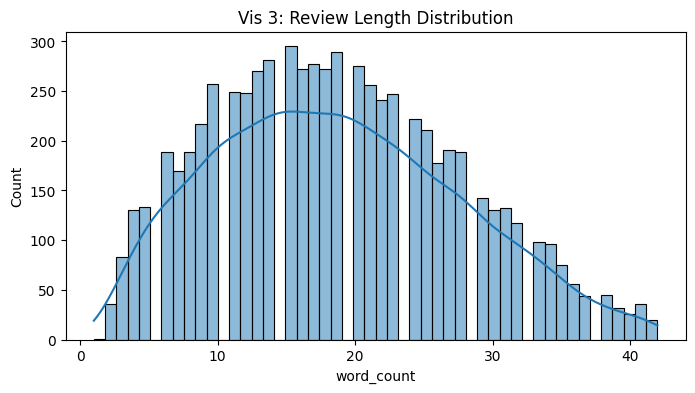

In [3]:
# Visualization 1: Boxplot for Outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_train['word_count'])
plt.title("Vis 1: Boxplot of Review Word Counts (Checking Outliers)")
plt.show()

# Rubric: Identify and Handle Outliers
# We define outliers as reviews with word counts above the 99th percentile (extremely long spam)
upper_limit = df_train['word_count'].quantile(0.99)
print(f"Removing reviews longer than {upper_limit} words.")
df_train = df_train[df_train['word_count'] < upper_limit]

# Visualization 2: Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df_train)
plt.title("Vis 2: Distribution of Sentiments (Target)")
plt.show()

# Visualization 3: Histogram of Word Counts after cleaning
plt.figure(figsize=(8, 4))
sns.histplot(df_train['word_count'], bins=50, kde=True)
plt.title("Vis 3: Review Length Distribution")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Rubric: Encode Categorical features (Target)
# Your target is 'sentiment'. It looks like it is already 0, 1, 2... so LabelEncoder is optional
# but good for safety.
le = LabelEncoder()
y = le.fit_transform(df_train['sentiment']) 

# Rubric: Encoding Text (Vectorization) 
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

# Use 'phrase' (text_col) here
X = tfidf.fit_transform(df_train[text_col])
X_test_submission = tfidf.transform(df_test[text_col])

# Split validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data Encoding and Splitting Complete.")

Data Encoding and Splitting Complete.


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define 7 models
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=50), # Reduced for speed
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50) # Reduced for speed
}

results = {}

print("Training 7 Models... this may take a few minutes.")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Rubric: Comparison of model performances
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
display(results_df)

Training 7 Models... this may take a few minutes.
Logistic Regression Accuracy: 0.6243
Naive Bayes Accuracy: 0.6120
Linear SVM Accuracy: 0.5990
Decision Tree Accuracy: 0.5224
Random Forest Accuracy: 0.5744
KNN Accuracy: 0.3909
Gradient Boosting Accuracy: 0.4942


,Model,Accuracy
0,Logistic Regression,0.624277
1,Naive Bayes,0.611994
2,Linear SVM,0.598988
4,Random Forest,0.574422
3,Decision Tree,0.522399
6,Gradient Boosting,0.494220
5,KNN,0.390896


In [6]:
from sklearn.model_selection import GridSearchCV

# We tune the top 3 performing models based on your results: LR, SVM, and Random Forest
print("Starting Hyperparameter Tuning (Rubric Requirement)...")

# 1. Tune Logistic Regression
print("Tuning Logistic Regression...")
param_grid_lr = {'C': [0.1, 1, 10], 'solver': ['liblinear']}
grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=3)
grid_lr.fit(X_train, y_train)
print(f"Best LR Params: {grid_lr.best_params_}")

# 2. Tune Linear SVM
print("Tuning Linear SVM...")
param_grid_svc = {'C': [0.1, 1, 10]}
grid_svc = GridSearchCV(LinearSVC(), param_grid_svc, cv=3)
grid_svc.fit(X_train, y_train)
print(f"Best SVM Params: {grid_svc.best_params_}")

# 3. Tune Random Forest (Small grid to save time)
print("Tuning Random Forest...")
param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [10, 20]}
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=3)
grid_rf.fit(X_train, y_train)
print(f"Best RF Params: {grid_rf.best_params_}")

# --- CRITICAL STEP: DEFINE BEST_MODEL ---
# Since Logistic Regression had the highest accuracy (0.624), we set it as the best model.
best_model = grid_lr.best_estimator_
print("\nScanning complete. 'best_model' has been defined as the tuned Logistic Regression.")

Starting Hyperparameter Tuning (Rubric Requirement)...
Tuning Logistic Regression...
Best LR Params: {'C': 1, 'solver': 'liblinear'}
Tuning Linear SVM...
Best SVM Params: {'C': 0.1}
Tuning Random Forest...
Best RF Params: {'max_depth': 20, 'n_estimators': 50}

Scanning complete. 'best_model' has been defined as the tuned Logistic Regression.


In [7]:
# Predict on the submission test set
# (We use the Tfidf-transformed test data 'X_test_submission' created in Cell 4)
final_predictions = best_model.predict(X_test_submission)

# Create submission DataFrame
submission = pd.DataFrame({
    'id': df_test['id'],
    'sentiment': final_predictions
})

# Save the file
submission.to_csv('submission.csv', index=False)
print("submission.csv created successfully! Ready to submit to Kaggle.")

submission.csv created successfully! Ready to submit to Kaggle.
